In [5]:
import torch
import numpy as np
import scipy
import pytorch_lightning as pl
from tqdm import tqdm
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
torch.set_float32_matmul_precision('medium')
import multiprocessing as mp
mp.set_start_method("spawn", force=True)

import multiprocessing
# multiprocessing.set_start_method('spawn')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import os, sys

sys.path.append("../../mist-base")
sys.path.append('../../')

from src.simulators.fd_simulators import GW_Additive_F, GW_Additive_F_Correlated
from simulators.utils import *
from utils.data import OnTheFlyDataModule, StoredDataModule
from utils.module import CustomLossModule_withBounds, BCELossModule, NewLossModule_withBounds
from models.online_norm import OnlineStandardizingLayer
from models.resnet_1d import ResidualNet

import plotfancy as pf
pf.housestyle_rcparams()

mycolors = ['#570f6d', '#bb3754', '#f98e08']
quantiles = np.array([0.05199686, 0.2145543,  0.58780088, 1.17737921, 1.91882754,
 2.75067576, 3.63463655])/np.sqrt(2)

quantiles_long = np.array([7.11978022e-04, 7.96148769e-03, 5.19968566e-02, 2.14554300e-01,
 5.87800876e-01, 1.17737921e+00, 1.91882754e+00, 2.75067576e+00,
 3.63463655e+00, 4.55164698e+00, 5.49045819e+00])/np.sqrt(2)

netid = 'GW_semicomplex2'


In [6]:
simulator_blank = GW_Additive_F(bkg=True, fraction=0.0002)
Nbins=simulator_blank.Nbins
del simulator_blank

In [7]:
class Network_epsilon(torch.nn.Module):
    def __init__(self, nbins):
        super().__init__()
        
        self.nbins = nbins

        self.logvariance = torch.nn.Parameter(torch.ones(self.nbins)*5)

        self.net = ResidualNet(1, 1, hidden_features=128, num_blocks=2, kernel_size=1, padding=0) 
        self.mu_predictor = torch.nn.Sequential(
            torch.nn.Linear(self.nbins, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, self.nbins)
        )# NOTE: This network doesn't actually learn mu - instead the semi-difference across the magnitudes

    def mu(self, x):
        x = self.mu_predictor(x.unsqueeze(1)).squeeze(1)
        return x
                
    def epsilon(self, x):
        resd = x - self.mu(x)
        out = self.net(resd.unsqueeze(1)).squeeze(1) # x-net
        return out
    
    def snr(self, x):
        return self.epsilon(x) / self.logvariance.exp().sqrt()  # [B, N_bins]
    
    def bounds(self):
        return self.logvariance.detach().exp().sqrt().mean(-1) * 10

        
    def forward(self, x):
        
        noise_block = torch.nan_to_num(x['noise'], nan=0, posinf=0, neginf=0)
        x0_block = torch.nan_to_num(x['x0'], nan=0, posinf=0, neginf=0)
        # mu_block = torch.nan_to_num(x['mu'], nan=0, posinf=0, neginf=0)
        ni = torch.nan_to_num(x['ni'], nan=0, posinf=0, neginf=0).real
        
        ###########################################
        epsilon_sim =  2 * self.bounds() * (torch.rand(torch.abs(x0_block).shape, 
                                                           device= x0_block.device, 
                                                           dtype= torch.abs(x0_block).dtype) - 1) * ni
        ###########################################

        data_mu = torch.abs(x0_block)+epsilon_sim
        data_noise = torch.abs(noise_block)+epsilon_sim
        data_diff = data_mu-data_noise # We are not actually finding mu here, instead it's more like a weird complex differnec

        # net evaluation_m
        net_mu = self.mu(data_mu)
        error_mu = (net_mu-data_diff)**2 # network's aim is to learn the diff here
        l_mu = error_mu / (self.logvariance.exp() + 1e-10) + self.logvariance
        l_mu_return = l_mu.sum() * 0.5

        # net evaluation_e
        net_epsilon = self.epsilon(data_mu)
        mask = ( ni.real != 0 )  
        squared_error_e = (net_epsilon - epsilon_sim)**2                                         # [B, N_bins]
        l_e = squared_error_e / (self.logvariance.exp() + 1e-21) + self.logvariance                   # [B, N_bins]
        l_e_return = (l_e * mask.float()).sum() * 0.5
        
        # combine
        return l_mu_return+l_e_return


In [8]:
network_epsilon = Network_epsilon(Nbins)
checkpoint = torch.load(f'networks/network_{netid}', 
                        weights_only=False,map_location=torch.device('cpu'))
sd = checkpoint.state_dict()
new_state_dict = {}
for key in sd:
    new_key = key.replace('model.', '')  # Remove 'model.' prefix
    new_state_dict[new_key] = sd[key]
    
network_epsilon.load_state_dict(new_state_dict)
network_epsilon.cuda().double().eval()

model = CustomLossModule_withBounds(network_epsilon, learning_rate=3e-3)
checkpoint = torch.load(f'networks/model_{netid}', 
                        weights_only=False,map_location=torch.device('cpu'))
sd = checkpoint.state_dict()
for key in sd:
    new_key = key.replace('model.', '')  # Remove 'model.' prefix
    new_state_dict[new_key] = sd[key]
    
model.load_state_dict(sd)
network_epsilon.cuda().double().eval()
network_epsilon.cuda()

Network_epsilon(
  (net): ResidualNet(
    (initial_layer): Conv1d(1, 128, kernel_size=(1,), stride=(1,))
    (blocks): ModuleList(
      (0-1): 2 x ResidualBlock(
        (conv_layers): ModuleList(
          (0-1): 2 x Conv1d(128, 128, kernel_size=(1,), stride=(1,))
        )
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (final_layer): Conv1d(128, 1, kernel_size=(1,), stride=(1,))
  )
  (mu_predictor): Sequential(
    (0): Linear(in_features=4097, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4097, bias=True)
  )
)

In [9]:
simulator = GW_Additive_F(bkg=True, fraction=0.0002)

In [10]:
N_mc = 5e5

batch_size = 2**8
N_batch = int(N_mc / batch_size)

ts_bin_H0_epsilon = []
for _ in tqdm(range(N_batch)):
    mc_samples = simulator.sample(batch_size)
    cleaned = torch.abs(torch.nan_to_num(mc_samples['x0'], nan=0))
    ts_batch =  (network_epsilon.snr(cleaned.cuda())**2).detach().cpu().numpy()
    ts_bin_H0_epsilon.append(ts_batch)
    
ts_bin_H0_epsilon = np.concatenate(ts_bin_H0_epsilon)

ts_sum_H0_epsilon = ts_bin_H0_epsilon.sum(axis=1)
ts_sum_H0_epsilon_mean = ts_sum_H0_epsilon.mean()
ts_sum_H0_epsilon = ts_sum_H0_epsilon - ts_sum_H0_epsilon_mean

  0%|          | 0/1953 [00:00<?, ?it/s]

100%|██████████| 1953/1953 [13:06<00:00,  2.48it/s]


In [11]:
def chop_middle(array, remove=5, linemode=True):
    if len(array)%2==0:
        mid_u = int(len(array)/4)
        mid_d = mid_u -1
        if not linemode:
            return np.concatenate([array[:mid_d-remove], array[mid_u+remove:]])
        else:
            return array[:mid_d-remove] , array[mid_u+remove:], array[mid_u]
    else:
        mid = len(array)//2
        if not linemode:
            return np.concatenate([array[:mid-remove], array[mid+remove:]])
        else:
            return array[:mid-remove], array[mid+remove:], array[mid]
        
def get_snr2(input:dict):
    target = input['x']
    snr2_nn = network_epsilon.snr(target.cuda()).detach().cpu().numpy()**2 
    return snr2_nn

def local_do_ticks(list_of_axes, dir = 'in'):
    for ax in list_of_axes:
        ax.minorticks_on()
        ax.tick_params(top=True,right=True, direction=dir, length=7, which='major')
        ax.tick_params(top=True,right=True, direction=dir, length=4, which='minor')

def local_fix_frame(ax):
    ax.tick_params(color='black', labelcolor='black')
    ax.spines[:].set_color('black')
    ax.spines[:].set_linewidth(1)
    return True

def local_fix_plot(a, tickdir ='in'):
    for axes in a:
        axes.grid(False)
        local_do_ticks([axes], tickdir)
        local_fix_frame(axes)
    return True

def t_to_pvalue_empirical_vec(ts_obs, ts0_ref):
    counts = np.sum(ts0_ref >= ts_obs, axis=0)
    return (counts + 1) / (ts0_ref.shape[0] + 1)

def get_p_nn_vec(ts_bin_obs):
    m = ts_bin_H0_epsilon.mean(axis=0)
    ts0_ref = ts_bin_H0_epsilon - m
    ts_obs = ts_bin_obs - m
    return t_to_pvalue_empirical_vec(ts_obs, ts0_ref)

def get_stats(inputdata: torch.Tensor):
    # INPUT DATA NEEDS TO BE OF SHAPE NBIN
    to_nn = {'x':inputdata.unsqueeze(0)}
    tbin = get_snr2(to_nn).squeeze(0)
    pbin = get_p_nn_vec(tbin)
    return tbin, pbin

def pvalue_grid_eps(dat):
    eps_t_mean = np.mean(ts_bin_H0_epsilon, axis=0)
    eps_t_ref = ts_bin_H0_epsilon - eps_t_mean
    counts = np.sum(eps_t_ref >= dat[:, np.newaxis, :], axis=1)
    return (counts + 1) / (len(eps_t_ref) + 1)

def pvalue_grid_BCE(dat):
    BCE_t_mean = np.mean(ts_bin_H0_BCE, axis=0)
    BCE_t_ref = ts_bin_H0_BCE - BCE_t_mean
    counts = np.sum(BCE_t_ref >= dat[:, np.newaxis, :], axis=1)
    return (counts + 1) / (len(BCE_t_ref) + 1)

def pvalue_grid_eps_looped(dat):
    eps_t_mean = np.mean(ts_bin_H0_epsilon, axis=0)
    eps_t_ref = ts_bin_H0_epsilon - eps_t_mean
    counts = np.zeros_like(dat, dtype=int)
    for i in tqdm(range(dat.shape[0])):
        counts[i, :] = np.sum(eps_t_ref >= dat[i, :], axis=0)
    return (counts + 1) / (len(eps_t_ref) + 1)

In [31]:
###### SET UP GRID ######
positions = torch.tensor(np.array(simulator.frequencies))
amplitudes = torch.linspace(-3, 7, 500).to(dtype=simulator.dtype)

position_grid, amplitude_grid = torch.meshgrid(positions,amplitudes)
b = {'x':amplitude_grid.T}

gw150914 = np.abs(simulator.get_GW150914_fd())

###### DO BCE STATS ######
s = get_snr2(b)
dat = pvalue_grid_eps_looped(s)
plot = np.log10(dat)
lab =  [r'$\mathrm{log}_{10}($p$_{i, \mathrm{SNR}})$']


100%|██████████| 500/500 [11:36<00:00,  1.39s/it]


In [56]:
tensorin = torch.nan_to_num(torch.from_numpy(gw150914), nan=0)
tstat, pstat = get_stats(tensorin)

/tmp/ipykernel_1053934/45114260.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


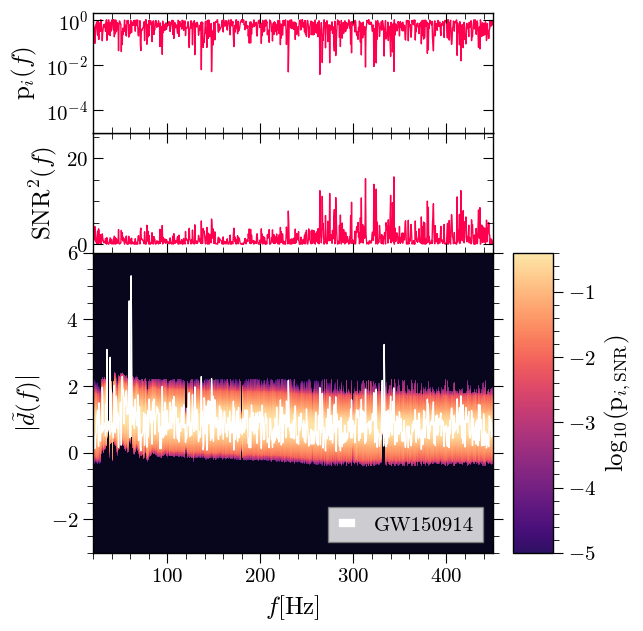

In [57]:
fig, ax1 = pf.create_plot()
ax1.set_xlabel(r'$f$[Hz]')
ax2 = fig.add_axes((1.05, 0,0.1,1))
ax3 = fig.add_axes((0,1,1,0.4), sharex=ax1)
plt.setp(ax3.get_xticklabels(), visible=False)
ax4 = fig.add_axes((0,1.4,1,0.4),sharex=ax1)
plt.setp(ax4.get_xticklabels(), visible=False)
axs= [ax1,ax2,ax3,ax4]

plot2 = plot.copy()
plot2[310:] = -5.69894308

mesh = ax1.pcolormesh(position_grid.T, amplitude_grid.T, plot2, cmap='magma', vmin=-6)
fig.colorbar(mesh,cax=ax2, shrink=0.8, label=lab[0])
ax2.set_ylim([-5,-0.4])
ax1.set_xlim([20,450])
ax1.set_ylim([-3,6])

ax1.plot(simulator.frequencies, gw150914, linewidth=1, color='w', label='GW150914')

ax1.set_ylabel(r'$|\tilde{d}(f)|$')
ax1.legend(loc='lower right')

ax3.plot(simulator.frequencies, tstat, color='#ff004f', linewidth=1)

ax3.set_ylabel(r'$\mathrm{SNR}^2(f)$')
ax3.set_ylim([-2,26])

ax4.semilogy(simulator.frequencies, pstat, color='#ff004f', linewidth=1)

ax4.set_ylabel(r'$\mathrm{p}_i(f)$')
ax4.set_ylim([1e-5,2])
ax4.set_yticks([1e-4,1e-2,1])

local_fix_plot([ax1,ax2], tickdir='out')
pf.fix_plot([ax3,ax4])
plt.tight_layout()
plt.savefig(f'figs/{netid}/heatmapfull.png', dpi=700, bbox_inches = 'tight')


/tmp/ipykernel_1053934/2681312131.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


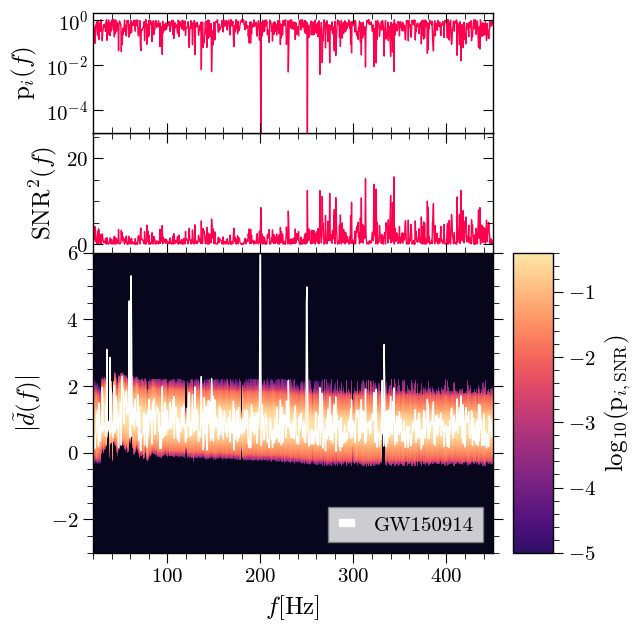

In [58]:
def apply_gaussian_peak(data_array, peak_position, amplitude, width=1.0):
    n = len(data_array)
    x = np.arange(n)
    # Generate the Gaussian curve centered at peak_position
    gaussian = amplitude * np.exp(-((x - peak_position)**2) / (2 * width**2))
    # Create a baseline of ones and add the Gaussian
    output_array = np.ones(n) + gaussian
    return output_array

mask = (apply_gaussian_peak(gw150914, 400, 10)+apply_gaussian_peak(gw150914,500,8))/2
simerr = gw150914*mask

tensorin = torch.nan_to_num(torch.from_numpy(simerr), nan=0)
tstat, pstat = get_stats(tensorin)

fig, ax1 = pf.create_plot()
ax1.set_xlabel(r'$f$[Hz]')
ax2 = fig.add_axes((1.05, 0,0.1,1))
ax3 = fig.add_axes((0,1,1,0.4), sharex=ax1)
plt.setp(ax3.get_xticklabels(), visible=False)
ax4 = fig.add_axes((0,1.4,1,0.4),sharex=ax1)
plt.setp(ax4.get_xticklabels(), visible=False)
axs= [ax1,ax2,ax3,ax4]

plot2 = plot.copy()
plot2[310:] = -5.69894308

mesh = ax1.pcolormesh(position_grid.T, amplitude_grid.T, plot2, cmap='magma', vmin=-6)
fig.colorbar(mesh,cax=ax2, shrink=0.8, label=lab[0])
ax2.set_ylim([-5,-0.4])
ax1.set_xlim([20,450])
ax1.set_ylim([-3,6])

ax1.plot(simulator.frequencies, simerr, linewidth=1, color='w', label='GW150914')

ax1.set_ylabel(r'$|\tilde{d}(f)|$')
ax1.legend(loc='lower right')

ax3.plot(simulator.frequencies, tstat, color='#ff004f', linewidth=1)

ax3.set_ylabel(r'$\mathrm{SNR}^2(f)$')
ax3.set_ylim([-2,26])

ax4.semilogy(simulator.frequencies, pstat, color='#ff004f', linewidth=1)

ax4.set_ylabel(r'$\mathrm{p}_i(f)$')
ax4.set_ylim([1e-5,2])
ax4.set_yticks([1e-4,1e-2,1])

local_fix_plot([ax1,ax2], tickdir='out')
pf.fix_plot([ax3,ax4])
plt.tight_layout()
plt.savefig(f'figs/{netid}/heatmapwerr.png', dpi=700, bbox_inches = 'tight')


/tmp/ipykernel_1053934/2218102761.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


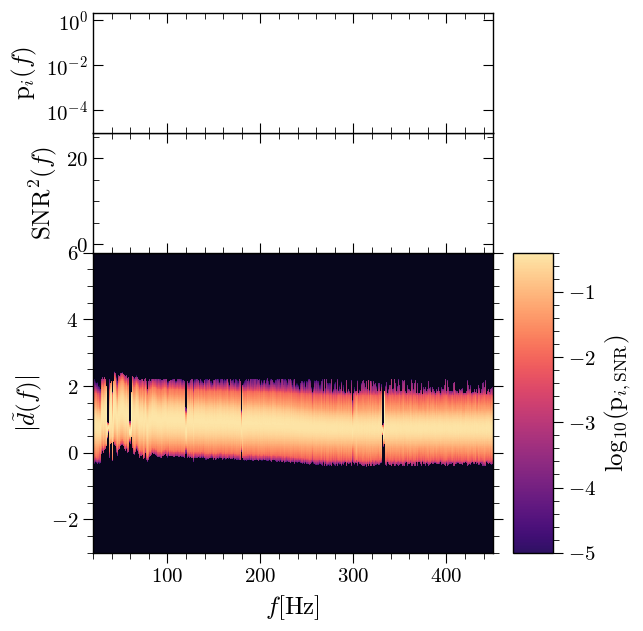

In [59]:
fig, ax1 = pf.create_plot()
ax1.set_xlabel(r'$f$[Hz]')
ax2 = fig.add_axes((1.05, 0,0.1,1))
ax3 = fig.add_axes((0,1,1,0.4), sharex=ax1)
plt.setp(ax3.get_xticklabels(), visible=False)
ax4 = fig.add_axes((0,1.4,1,0.4),sharex=ax1)
plt.setp(ax4.get_xticklabels(), visible=False)
axs= [ax1,ax2,ax3,ax4]

plot2 = plot.copy()
plot2[310:] = -5.69894308

mesh = ax1.pcolormesh(position_grid.T, amplitude_grid.T, plot2, cmap='magma', vmin=-6)
fig.colorbar(mesh,cax=ax2, shrink=0.8, label=lab[0])
ax2.set_ylim([-5,-0.4])
ax1.set_xlim([20,450])
ax1.set_ylim([-3,6])

# ax1.plot(simulator.frequencies, gw150914, linewidth=1, color='w', label='GW150914')

ax1.set_ylabel(r'$|\tilde{d}(f)|$')
# ax1.legend(loc='lower right')

ax3.plot(simulator.frequencies, tstat, color='#ffffff', linewidth=1)

ax3.set_ylabel(r'$\mathrm{SNR}^2(f)$')
ax3.set_ylim([-2,26])

ax4.semilogy(simulator.frequencies, pstat, color='#ffffff', linewidth=1)

ax4.set_ylabel(r'$\mathrm{p}_i(f)$')
ax4.set_ylim([1e-5,2])
ax4.set_yticks([1e-4,1e-2,1])

local_fix_plot([ax1,ax2], tickdir='out')
pf.fix_plot([ax3,ax4])
plt.tight_layout()
plt.savefig(f'figs/{netid}/heatmapnostuff.png', dpi=700, bbox_inches = 'tight')
